La libreria antes se llamaba yahoo_finance, actualmente es yfinance

In [1]:
!pip install yfinance numpy matplotlib tensorflow --quiet

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yfinance as yf
import random
import warnings
from collections import Counter
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Prueba basica: precio actual de Microsoft
msft  = yf.Ticker('MSFT')
info  = msft.fast_info

open_price = info.open
last_price = info.last_price
cambio_pct = (last_price - open_price) / open_price * 100

print('------------------------------------------')
print('  Ticker:          MSFT (Microsoft)')
print(f'  Precio apertura: ${open_price:.2f}')
print(f'  Precio actual:   ${last_price:.2f}')
print(f'  Variacion dia:   {cambio_pct:+.2f}%')
print('------------------------------------------')

------------------------------------------
  Ticker:          MSFT (Microsoft)
  Precio apertura: $367.21
  Precio actual:   $373.46
  Variacion dia:   +1.70%
------------------------------------------


**1. `get_prices()` — Cambio de API:**
- `Share(symbol).get_historical()` reemplazado por `yf.Ticker(symbol).history()` por deprecación de la librería original.
- Se agrega `allow_pickle=True` en `np.load` para compatibilidad con NumPy moderno.

**2. `plot_prices()` — Mejoras visuales:**
- Se agrega `figsize` para gráfico más legible.
- Se incluye `grid`, marcadores de mínimo/máximo y estadísticas descriptivas.

**3. Rango de fechas actualizado:** `2000-07-01 → 2017-07-01` cambiado a `2007-01-01 → 2024-12-31` para trabajar con datos actuales.

In [5]:
def get_prices(share_symbol, start_date, end_date, cache_filename):
    """
    Descarga o carga desde cache los precios historicos de apertura.
    MODIFICADO: usa yfinance en lugar de la libreria yahoo_finance deprecada.
    """
    try:
        stock_prices = np.load(cache_filename, allow_pickle=True)
        print(f'Datos cargados desde cache: {cache_filename} ({len(stock_prices)} dias)')
    except IOError:
        print(f'Descargando datos de {share_symbol} ({start_date} a {end_date})...')
        ticker       = yf.Ticker(share_symbol)
        stock_hist   = ticker.history(start=start_date, end=end_date)
        stock_prices = stock_hist['Open'].values.astype(float)
        np.save(cache_filename, stock_prices)
        print(f'Datos guardados en: {cache_filename} ({len(stock_prices)} dias)')
    return stock_prices


def plot_prices(prices, symbol='', start='', end=''):
    """
    Visualiza la serie historica de precios de apertura.
    MODIFICADO: mejoras visuales y estadisticas adicionales.
    """
    fig, ax = plt.subplots(figsize=(13, 4))

    ax.plot(prices, color='steelblue', linewidth=1)
    ax.fill_between(range(len(prices)), prices, alpha=0.1, color='steelblue')

    # Marcar precio minimo y maximo
    idx_min = int(np.argmin(prices))
    idx_max = int(np.argmax(prices))
    ax.scatter(idx_min, prices[idx_min], color='red',   zorder=5, s=60,
               label=f'Min ${prices[idx_min]:.2f}')
    ax.scatter(idx_max, prices[idx_max], color='green', zorder=5, s=60,
               label=f'Max ${prices[idx_max]:.2f}')

    title = f'Opening Stock Prices - {symbol}'
    if start and end:
        title += f'  ({start} a {end})'
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Dia de trading')
    ax.set_ylabel('Precio de apertura ($)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('prices.png', dpi=150)
    plt.show()

    retorno = (prices[-1] - prices[0]) / prices[0] * 100
    print(f'\nEstadisticas - {symbol}')
    print(f'  Total dias de trading : {len(prices):,}')
    print(f'  Precio minimo         : ${prices.min():.2f}  (dia {idx_min})')
    print(f'  Precio maximo         : ${prices.max():.2f}  (dia {idx_max})')
    print(f'  Precio promedio       : ${prices.mean():.2f}')
    print(f'  Precio inicial        : ${prices[0]:.2f}')
    print(f'  Precio final          : ${prices[-1]:.2f}')
    print(f'  Retorno total periodo : {retorno:+.1f}%')


print('Funciones get_prices y plot_prices definidas.')

Funciones get_prices y plot_prices definidas.


Descargando datos de MSFT (2007-01-01 a 2024-12-31)...
Datos guardados en: hist_MSFT.npy (4529 dias)


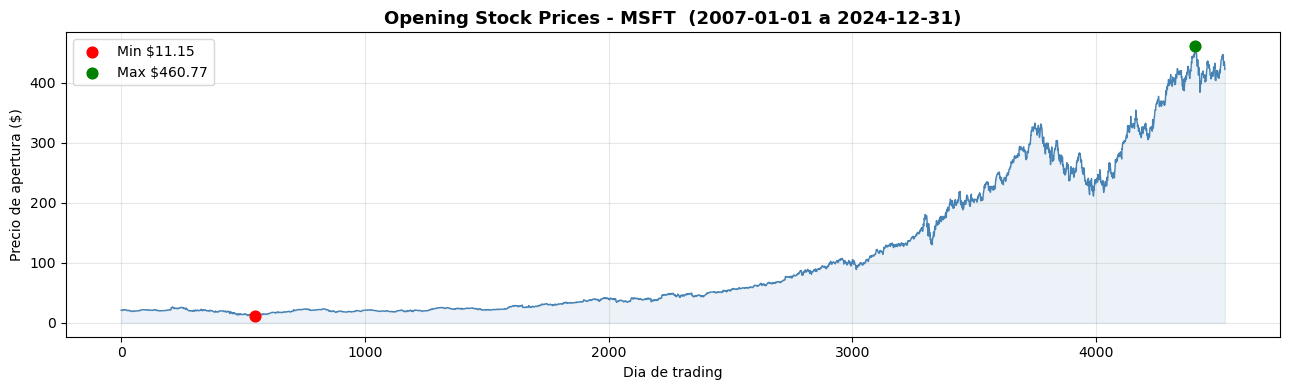


Estadisticas - MSFT
  Total dias de trading : 4,529
  Precio minimo         : $11.15  (dia 548)
  Precio maximo         : $460.77  (dia 4407)
  Precio promedio       : $110.25
  Precio inicial        : $21.11
  Precio final          : $421.98
  Retorno total periodo : +1899.0%


In [6]:
# Parametros globales
SYMBOL     = 'MSFT'
START_DATE = '2007-01-01'
END_DATE   = '2024-12-31'
CACHE_FILE = f'hist_{SYMBOL}.npy'

prices = get_prices(SYMBOL, START_DATE, END_DATE, CACHE_FILE)
plot_prices(prices, symbol=SYMBOL, start=START_DATE, end=END_DATE)

El codigo original se mantiene **sin cambios estructurales**. Se añadieron unicamente **docstrings** en cada clase y un metodo `__repr__` para identificar la politica en salidas de consola. Estos cambios son de documentacion, no de logica.

In [7]:
class DecisionPolicy:
    """Clase base abstracta para politicas de decision de trading."""

    def select_action(self, current_state, step):
        """Selecciona una accion dado el estado actual. Debe sobreescribirse."""
        pass

    def update_q(self, state, action, reward, next_state):
        """Actualiza la funcion Q con la experiencia (s, a, r, s'). Debe sobreescribirse."""
        pass


class RandomDecisionPolicy(DecisionPolicy):
    """
    Politica de decision completamente aleatoria.
    Sirve como linea base (baseline) para comparar con politicas inteligentes.
    No utiliza el estado actual para tomar decisiones.
    """

    def __init__(self, actions):
        self.actions = actions

    def select_action(self, current_state, step):
        """Elige una accion uniformemente al azar (ignora el estado)."""
        return self.actions[random.randint(0, len(self.actions) - 1)]

    def __repr__(self):
        return f'RandomDecisionPolicy(acciones={self.actions})'


print('DecisionPolicy y RandomDecisionPolicy definidas.')

DecisionPolicy y RandomDecisionPolicy definidas.


| # | Cambio | Justificacion |
|---|---|---|
| 1 | Impresion de progreso solo con `debug=True` | El original imprimia siempre; con 100 simulaciones genera miles de lineas |
| 2 | `np.asmatrix` → `np.array(...).reshape(1,-1)` | `np.asmatrix` esta deprecado en NumPy moderno |
| 3 | `num_tries` como parametro en `run_simulations` | Permite controlar el numero de simulaciones sin modificar el codigo |
| 4 | Indicador de progreso en `run_simulations` | Retroalimentacion visual durante ejecuciones largas |

In [8]:
def run_simulation(policy, initial_budget, initial_num_stocks, prices, hist, debug=False):
    """
    Simula el agente de trading sobre la serie de precios historicos.
    MODIFICADO: np.asmatrix reemplazado por np.array (deprecacion);
    progreso solo en modo debug.
    """
    budget      = initial_budget
    num_stocks  = initial_num_stocks
    share_value = 0
    transitions = []

    for i in range(len(prices) - hist - 1):

        # Estado: ventana de hist precios + presupuesto + acciones
        # MODIFICACION: np.asmatrix (deprecado) -> np.array reshape
        current_state     = np.array(np.hstack((prices[i:i+hist], budget, num_stocks))).reshape(1, -1)
        current_portfolio = budget + num_stocks * share_value

        # Infer: seleccionar accion
        action      = policy.select_action(current_state, i)
        share_value = float(prices[i + hist + 1])

        # Do: ejecutar la accion
        if action == 'Buy' and budget >= share_value:
            budget     -= share_value
            num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget     += share_value
            num_stocks -= 1
        else:
            action = 'Hold'

        # Recompensa: delta portafolio
        new_portfolio = budget + num_stocks * share_value
        reward        = new_portfolio - current_portfolio

        # Siguiente estado
        next_state = np.array(np.hstack((prices[i+1:i+hist+1], budget, num_stocks))).reshape(1, -1)

        # Learn: guardar y actualizar Q
        transitions.append((current_state, action, reward, next_state))
        policy.update_q(current_state, action, reward, next_state)

    portfolio = budget + num_stocks * share_value
    if debug:
        print(f'  Presupuesto: ${budget:.2f}  |  Acciones: {num_stocks}  |  Portafolio: ${portfolio:.2f}')
    return portfolio


def run_simulations(policy, budget, num_stocks, prices, hist, num_tries=100):
    """
    Ejecuta multiples simulaciones y retorna promedio y desviacion estandar.
    MODIFICADO: num_tries ahora es parametro (original tenia 100 hardcodeado).
    """
    final_portfolios = []
    for t in range(num_tries):
        if (t + 1) % 25 == 0 or t == 0:
            print(f'  Simulacion {t+1:3d}/{num_tries}...')
        fp = run_simulation(policy, budget, num_stocks, prices, hist)
        final_portfolios.append(fp)
    return np.mean(final_portfolios), np.std(final_portfolios)


print('run_simulation y run_simulations definidas.')

run_simulation y run_simulations definidas.


In [9]:
# Hiperparametros del entorno de trading
ACTIONS    = ['Buy', 'Sell', 'Hold']
HIST       = 200      # ventana de precios historicos
BUDGET     = 1000.0   # presupuesto inicial en USD
NUM_STOCKS = 0        # acciones en cartera al inicio
NUM_TRIES  = 100      # simulaciones para estabilizar promedio

random_policy = RandomDecisionPolicy(ACTIONS)

print('Ejecutando 100 simulaciones con POLITICA ALEATORIA...')
print('(Puede tardar 1-2 minutos)\n')

avg_random, std_random = run_simulations(
    random_policy, BUDGET, NUM_STOCKS, prices, HIST, num_tries=NUM_TRIES
)

print(f'\nResultados - Politica Aleatoria (n={NUM_TRIES})')
print(f'  Presupuesto inicial :  ${BUDGET:.2f}')
print(f'  Portafolio promedio :  ${avg_random:.2f}')
print(f'  Desviacion estandar :  ${std_random:.2f}')
print(f'  Ganancia/Perdida    :  ${avg_random - BUDGET:+.2f}')
print(f'  Retorno             :  {(avg_random - BUDGET)/BUDGET*100:+.1f}%')

Ejecutando 100 simulaciones con POLITICA ALEATORIA...
(Puede tardar 1-2 minutos)

  Simulacion   1/100...
  Simulacion  25/100...
  Simulacion  50/100...
  Simulacion  75/100...
  Simulacion 100/100...

Resultados - Politica Aleatoria (n=100)
  Presupuesto inicial :  $1000.00
  Portafolio promedio :  $5574.53
  Desviacion estandar :  $2747.23
  Ganancia/Perdida    :  $+4574.53
  Retorno             :  +457.5%


| # | Elemento original | Elemento modificado | Justificacion |
|---|---|---|---|
| 1 | `tf.placeholder()` | Eliminado | Pertenece a TF 1.x. TF 2.x usa ejecucion inmediata (eager execution), sin grafos explicitos |
| 2 | `tf.Variable(tf.random_normal(...))` | `layers.Dense(kernel_initializer='random_normal')` | API Keras de alto nivel, mas clara y mantenible |
| 3 | `tf.Session()` + `sess.run()` | Eliminado | No existe en TF 2.x |
| 4 | `tf.train.GradientDescentOptimizer` | `keras.optimizers.Adam` | Adam converge mas rapido y de forma mas estable que SGD simple |
| 5 | `tf.initialize_all_variables()` | Eliminado | Keras inicializa variables automaticamente |
| 6 | Red de 1 capa oculta (200) | Red de 2 capas ocultas (200 + 100) | Mayor capacidad de representacion del espacio de estados |
| 7 | Activacion ReLU en salida | Activacion `linear` en salida | Los valores Q pueden ser negativos; ReLU en la salida los truncaria incorrectamente |
| 8 | `epsilon` y `gamma` fijos | Parametros del constructor | Permite experimentar sin modificar la clase |

In [10]:
class QLearningDecisionPolicy(DecisionPolicy):
    """
    Politica Q-Learning con red neuronal (Deep Q-Network simplificada).

    Arquitectura:
        Entrada  : 202 dimensiones (hist=200 precios + presupuesto + num_acciones)
        Oculta 1 : 200 neuronas, ReLU
        Oculta 2 : 100 neuronas, ReLU  (añadida respecto al original)
        Salida   : 3 valores Q (Buy, Sell, Hold), activacion lineal

    MODIFICADO completamente para compatibilidad con TensorFlow 2.x / Keras.
    """

    def __init__(self, actions, input_dim, epsilon=0.9, gamma=0.001, lr=0.005):
        self.actions = actions
        self.epsilon = epsilon
        self.gamma   = gamma
        output_dim   = len(actions)

        # Construccion del modelo con Keras (TF 2.x)
        # MODIFICACION: reemplaza el codigo TF 1.x con placeholders y Sessions
        self.model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(200, activation='relu',
                         kernel_initializer='random_normal',
                         bias_initializer=keras.initializers.Constant(0.1)),
            layers.Dense(100, activation='relu',
                         kernel_initializer='random_normal',
                         bias_initializer=keras.initializers.Constant(0.1)),
            # MODIFICACION: activacion lineal (no ReLU) para permitir valores Q negativos
            layers.Dense(output_dim, activation='linear')
        ])

        # MODIFICACION: Adam en lugar de GradientDescentOptimizer
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss='mse'
        )

    def select_action(self, current_state, step):
        """
        Estrategia epsilon-greedy con umbral creciente:
          - prob. threshold   -> explotacion: la red elige la mejor accion
          - prob. 1-threshold -> exploracion: accion aleatoria
        MODIFICADO: sess.run() -> model.predict()
        """
        threshold = min(self.epsilon, step / 1000.0)

        if random.random() < threshold:
            q_vals     = self.model.predict(current_state, verbose=0)[0]
            action_idx = np.argmax(q_vals)
        else:
            action_idx = random.randint(0, len(self.actions) - 1)

        return self.actions[action_idx]

    def update_q(self, state, action, reward, next_state):
        """
        Actualiza Q usando la ecuacion de Bellman:
            Q(s,a) <- reward + gamma * max_a' Q(s', a')
        MODIFICADO: sess.run() -> model.predict() y model.fit()
        """
        action_q_vals      = self.model.predict(state, verbose=0)[0]
        next_action_q_vals = self.model.predict(next_state, verbose=0)[0]
        next_action_idx    = np.argmax(next_action_q_vals)

        # Actualizacion Bellman
        action_idx = self.actions.index(action)
        action_q_vals[action_idx] = reward + self.gamma * next_action_q_vals[next_action_idx]

        self.model.fit(state, action_q_vals.reshape(1, -1), epochs=1, verbose=0)


print('QLearningDecisionPolicy definida.')
print()

# Mostrar resumen de la arquitectura
INPUT_DIM   = HIST + 2   # 202
demo_policy = QLearningDecisionPolicy(ACTIONS, INPUT_DIM)
demo_policy.model.summary()

QLearningDecisionPolicy definida.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │        40,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,003 (238.29 KB)

 Trainable params: 61,003 (238.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
ql_policy = QLearningDecisionPolicy(
    actions   = ACTIONS,
    input_dim = INPUT_DIM,
    epsilon   = 0.9,
    gamma     = 0.001,
    lr        = 0.005
)

print('Ejecutando simulacion con POLITICA Q-LEARNING...')
print('(Mas lenta por el entrenamiento de la red neuronal)\n')

ql_portfolio = run_simulation(
    ql_policy, BUDGET, NUM_STOCKS, prices, HIST, debug=True
)

print(f'\nResultados - Politica Q-Learning')
print(f'  Presupuesto inicial : ${BUDGET:.2f}')
print(f'  Portafolio final    : ${ql_portfolio:.2f}')
print(f'  Ganancia/Perdida    : ${ql_portfolio - BUDGET:+.2f}')
print(f'  Retorno             : {(ql_portfolio - BUDGET)/BUDGET*100:+.1f}%')

Ejecutando simulacion con POLITICA Q-LEARNING...
(Mas lenta por el entrenamiento de la red neuronal)

  Presupuesto: $214.59  |  Acciones: 53  |  Portafolio: $22579.36

Resultados - Politica Q-Learning
  Presupuesto inicial : $1000.00
  Portafolio final    : $22579.36
  Ganancia/Perdida    : $+21579.36
  Retorno             : +2157.9%


In [13]:
# Simulacion con tracking completo
def run_simulation_tracking(policy, initial_budget, initial_num_stocks, prices, hist):
    """Igual que run_simulation pero registra evolucion del portafolio y acciones."""
    budget        = initial_budget
    num_stocks    = initial_num_stocks
    share_value   = 0
    action_log    = []
    portfolio_log = []

    for i in range(len(prices) - hist - 1):
        current_state     = np.array(np.hstack((prices[i:i+hist], budget, num_stocks))).reshape(1,-1)
        current_portfolio = budget + num_stocks * share_value
        action            = policy.select_action(current_state, i)
        share_value       = float(prices[i + hist + 1])

        if action == 'Buy' and budget >= share_value:
            budget -= share_value;  num_stocks += 1
        elif action == 'Sell' and num_stocks > 0:
            budget += share_value;  num_stocks -= 1
        else:
            action = 'Hold'

        new_portfolio = budget + num_stocks * share_value
        reward        = new_portfolio - current_portfolio
        next_state    = np.array(np.hstack((prices[i+1:i+hist+1], budget, num_stocks))).reshape(1,-1)
        policy.update_q(current_state, action, reward, next_state)

        action_log.append(action)
        portfolio_log.append(new_portfolio)

    return portfolio_log, action_log


tracking_policy = QLearningDecisionPolicy(ACTIONS, INPUT_DIM, epsilon=0.9, gamma=0.001, lr=0.005)
print('Ejecutando simulacion con tracking...')
portfolio_log, action_log = run_simulation_tracking(
    tracking_policy, BUDGET, NUM_STOCKS, prices, HIST
)

action_counts = Counter(action_log)
total_steps   = len(action_log)

print(f'\nDistribucion de acciones (Q-Learning):')
for act in ['Buy', 'Sell', 'Hold']:
    cnt = action_counts.get(act, 0)
    bar = '#' * int(cnt / total_steps * 40)
    print(f'  {act:5s}: {cnt:5,d} ({cnt/total_steps*100:5.1f}%)  {bar}')

Ejecutando simulacion con tracking...

Distribucion de acciones (Q-Learning):
  Buy  :   348 (  8.0%)  ###
  Sell :   345 (  8.0%)  ###
  Hold : 3,635 ( 84.0%)  #################################


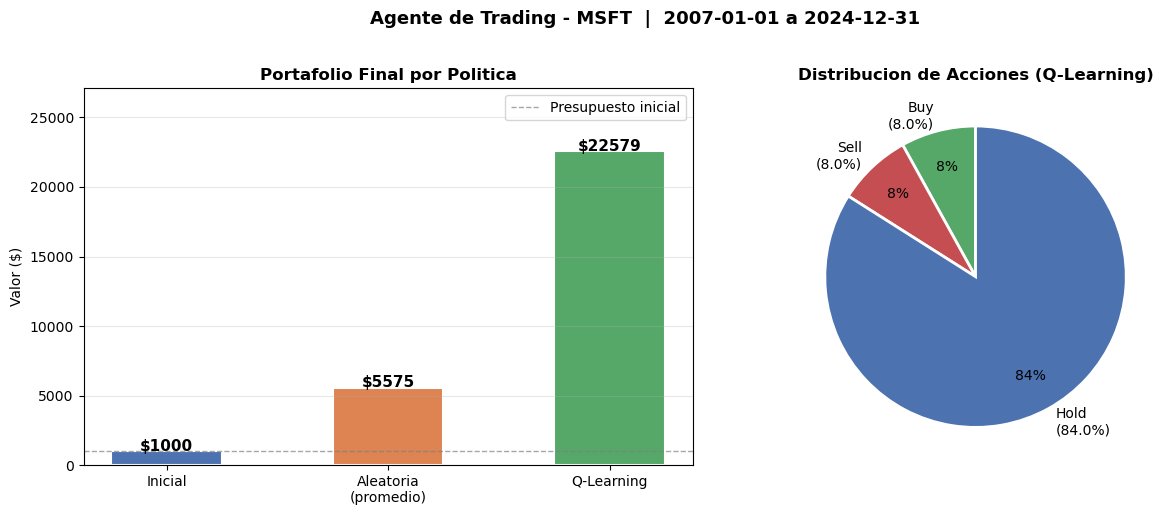

Grafica guardada: comparacion_portafolios.png


In [14]:
# FIGURA 1: Comparacion de portafolios y distribucion de acciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels  = ['Inicial', 'Aleatoria\n(promedio)', 'Q-Learning']
valores = [BUDGET, avg_random, ql_portfolio]
colores = ['#4C72B0', '#DD8452', '#55A868']
bars = axes[0].bar(labels, valores, color=colores, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'${val:.0f}', ha='center', fontsize=11, fontweight='bold')
axes[0].axhline(BUDGET, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Presupuesto inicial')
axes[0].set_title('Portafolio Final por Politica', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor ($)')
axes[0].set_ylim(0, max(valores) * 1.2)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

act_labels = ['Buy', 'Sell', 'Hold']
act_vals   = [action_counts.get(a, 0) for a in act_labels]
act_colors = ['#55A868', '#C44E52', '#4C72B0']
axes[1].pie(act_vals,
            labels=[f"{a}\n({v/total_steps*100:.1f}%)" for a, v in zip(act_labels, act_vals)],
            colors=act_colors, autopct='%1.0f%%', startangle=90, pctdistance=0.75,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Distribucion de Acciones (Q-Learning)', fontsize=12, fontweight='bold')

plt.suptitle(f'Agente de Trading - {SYMBOL}  |  {START_DATE} a {END_DATE}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacion_portafolios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: comparacion_portafolios.png')

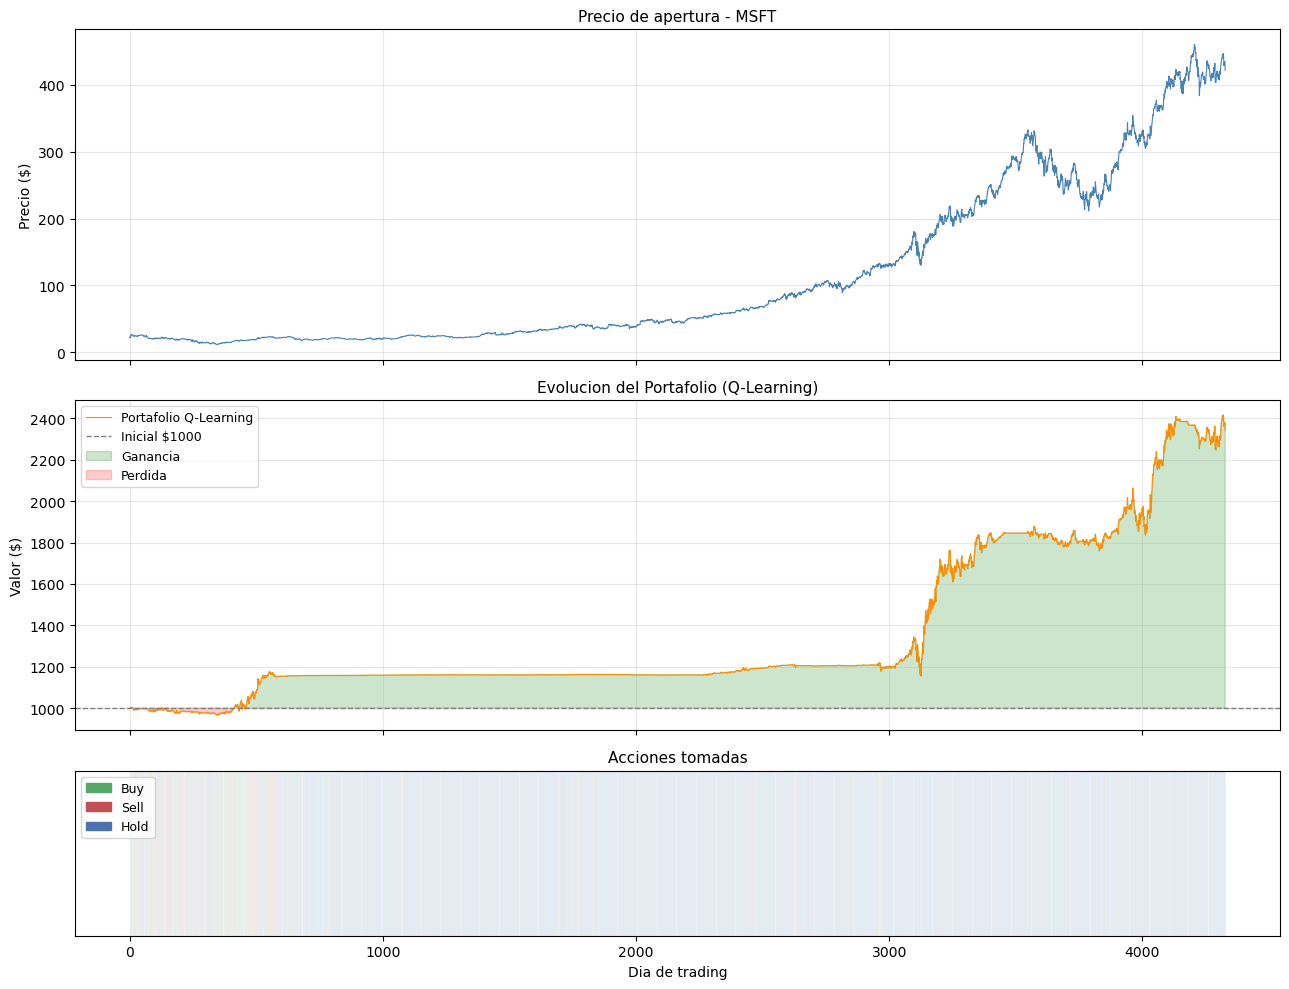

Grafica guardada: evolucion_portafolio.png


In [15]:
# FIGURA 2: Evolucion del portafolio vs precio de la accion
precio_plot = prices[HIST+1:]

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True,
                         gridspec_kw={'height_ratios': [2, 2, 1]})

# Panel 1: precio de la accion
axes[0].plot(precio_plot, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Precio de apertura - {SYMBOL}', fontsize=11)
axes[0].set_ylabel('Precio ($)')
axes[0].grid(alpha=0.3)

# Panel 2: evolucion del portafolio
axes[1].plot(portfolio_log, color='darkorange', linewidth=0.8, label='Portafolio Q-Learning')
axes[1].axhline(BUDGET, color='gray', linestyle='--', linewidth=1, label=f'Inicial ${BUDGET:.0f}')
axes[1].fill_between(range(len(portfolio_log)), BUDGET, portfolio_log,
                     where=[p >= BUDGET for p in portfolio_log],
                     alpha=0.2, color='green', label='Ganancia')
axes[1].fill_between(range(len(portfolio_log)), BUDGET, portfolio_log,
                     where=[p < BUDGET for p in portfolio_log],
                     alpha=0.2, color='red', label='Perdida')
axes[1].set_title('Evolucion del Portafolio (Q-Learning)', fontsize=11)
axes[1].set_ylabel('Valor ($)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Panel 3: acciones tomadas
color_map = {'Buy': '#55A868', 'Sell': '#C44E52', 'Hold': '#4C72B0'}
for idx, act in enumerate(action_log):
    axes[2].axvline(idx, color=color_map[act], alpha=0.05, linewidth=0.5)
axes[2].set_title('Acciones tomadas', fontsize=11)
axes[2].set_xlabel('Dia de trading')
axes[2].set_yticks([])
patches = [mpatches.Patch(color=color_map[a], label=a) for a in ['Buy','Sell','Hold']]
axes[2].legend(handles=patches, fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('evolucion_portafolio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafica guardada: evolucion_portafolio.png')

In [16]:
print('=' * 55)
print('     RESUMEN FINAL - AGENTE DE TRADING RL')
print('=' * 55)
print(f'  Accion analizada   : {SYMBOL}')
print(f'  Periodo            : {START_DATE} a {END_DATE}')
print(f'  Dias de datos      : {len(prices):,}')
print(f'  Presupuesto inicial: ${BUDGET:.2f}')
print('-' * 55)
print(f'  Politica ALEATORIA')
print(f'    Portafolio (prom): ${avg_random:.2f}')
print(f'    Desv. estandar   : ${std_random:.2f}')
print(f'    Retorno promedio : {(avg_random-BUDGET)/BUDGET*100:+.1f}%')
print('-' * 55)
print(f'  Politica Q-LEARNING')
print(f'    Portafolio final : ${ql_portfolio:.2f}')
print(f'    Retorno          : {(ql_portfolio-BUDGET)/BUDGET*100:+.1f}%')
print('-' * 55)
print(f'  Mejora Q-L vs Aleatoria: ${ql_portfolio - avg_random:+.2f}')
print('=' * 55)

     RESUMEN FINAL - AGENTE DE TRADING RL
  Accion analizada   : MSFT
  Periodo            : 2007-01-01 a 2024-12-31
  Dias de datos      : 4,529
  Presupuesto inicial: $1000.00
-------------------------------------------------------
  Politica ALEATORIA
    Portafolio (prom): $5574.53
    Desv. estandar   : $2747.23
    Retorno promedio : +457.5%
-------------------------------------------------------
  Politica Q-LEARNING
    Portafolio final : $22579.36
    Retorno          : +2157.9%
-------------------------------------------------------
  Mejora Q-L vs Aleatoria: $+17004.83
